# Solar-system orrery - from JPL's ephemeris to a live sky

We load JPL's **DE440** planetary ephemeris, compute heliocentric **J2000-ecliptic** planet positions, validate them against the independent **JPL Horizons** service, recover **Kepler's third law** from the kernel, and draw a top-down orrery. The live, scrubbable version is `scripts/orrery.py` (`streamlit run`).

> Validation has two layers: Horizons checks our *usage* (frame, centre, light-time) since it shares the same JPL ephemeris; **Kepler III** is the independent *physics* check.

In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path.cwd()))
import numpy as np
import matplotlib.pyplot as plt
from scripts.ephemeris import (heliocentric_ecliptic, orbital_period, semi_major_axis,
                               orbit_track, PLANETS, _load)
ts, eph = _load()
print('loaded de440s; bodies:', PLANETS)

loaded de440s; bodies: ['mercury', 'venus', 'earth', 'mars', 'jupiter', 'saturn', 'uranus', 'neptune']


## 1. Where is everything today?

`heliocentric_ecliptic(body, t)` returns the geometric heliocentric position (AU, J2000 ecliptic). We subtract the **Sun** and rotate the ICRF vector about x by the obliquity eps = 84381.448 arcsec.

In [2]:
t = ts.utc(2026, 6, 12)
print(f"{'body':9s}{'r (AU)':>9s}{'ecl lon':>9s}")
for b in PLANETS:
    x, y, z = heliocentric_ecliptic(b, t)
    r = np.sqrt(x*x + y*y + z*z); lon = np.degrees(np.arctan2(y, x)) % 360
    print(f'{b:9s}{r:9.3f}{lon:9.1f}')

body        r (AU)  ecl lon
mercury      0.416    199.9
venus        0.720    176.7
earth        1.015    260.7
mars         1.422     24.5
jupiter      5.270    122.2
saturn       9.469      7.0
uranus      19.461     61.4
neptune     29.881      2.0


## 2. Validate against JPL Horizons

The cached Horizons vectors (`data/reference/horizons_positions.csv`) are an independent NASA computation. Our fixed-**J2000** obliquity rotation matches them to ~1e-10 AU.

**The wrong turn:** Skyfield's `framelib.ecliptic_frame` is the ecliptic & equinox *of date*, so it precesses away from Horizons' J2000 ecliptic - the error **grows with epoch** (a passing but unexplained, time-dependent residual). The fixed `ecliptic_J2000_frame` is right.

In [3]:
from skyfield.framelib import ecliptic_frame, ecliptic_J2000_frame
idn = {'mercury':1,'venus':2,'earth':399,'mars':4,'jupiter':5,'saturn':6}
rows = np.loadtxt('data/reference/horizons_positions.csv', delimiter=',', skiprows=1, dtype=str)
names = rows[:, 0]; jd = rows[:, 1].astype(float); ref = rows[:, 2:5].astype(float)
d_hand, d_j2000, d_ofdate = [], [], []
for nm, j, rxyz in zip(names, jd, ref):
    tt = ts.tdb_jd(j); vec = (eph[idn[nm]] - eph[10]).at(tt)
    d_hand.append(np.linalg.norm(heliocentric_ecliptic(nm, tt) - rxyz))
    d_j2000.append(np.linalg.norm(vec.frame_xyz(ecliptic_J2000_frame).au - rxyz))
    d_ofdate.append(np.linalg.norm(vec.frame_xyz(ecliptic_frame).au - rxyz))
print(f'by-hand J2000 rotation   : max |d| = {max(d_hand):.2e} AU')
print(f'ecliptic_J2000_frame     : max |d| = {max(d_j2000):.2e} AU')
print(f'ecliptic_frame (of date) : max |d| = {max(d_ofdate):.2e} AU  <- precesses; grows w/ epoch')
jup = names == 'jupiter'
for j, d in sorted(zip(jd[jup], np.array(d_ofdate)[jup])):
    print(f'   jupiter of-date residual at JD {j:.0f}: {d:.2e} AU')

by-hand J2000 rotation   : max |d| = 7.59e-11 AU
ecliptic_J2000_frame     : max |d| = 7.59e-11 AU
ecliptic_frame (of date) : max |d| = 6.13e-02 AU  <- precesses; grows w/ epoch
   jupiter of-date residual at JD 2451544: 3.37e-04 AU
   jupiter of-date residual at JD 2455362: 1.31e-02 AU
   jupiter of-date residual at JD 2461204: 3.42e-02 AU


## 3. Kepler's third law, recovered from the kernel

Recover each planet's sidereal period (longitude advancing by 2pi) and semi-major axis ((r_min+r_max)/2). In solar units **P^2(yr) = a^3(AU)** - the identity line.

mercury   P=   0.241 yr  a=  0.387 AU  P^2/a^3=1.0000
venus     P=   0.615 yr  a=  0.723 AU  P^2/a^3=1.0000
earth     P=   1.000 yr  a=  1.000 AU  P^2/a^3=1.0000
mars      P=   1.881 yr  a=  1.524 AU  P^2/a^3=1.0000
jupiter   P=  11.860 yr  a=  5.203 AU  P^2/a^3=0.9987
saturn    P=  29.430 yr  a=  9.531 AU  P^2/a^3=1.0003
uranus    P=  84.012 yr  a= 19.189 AU  P^2/a^3=0.9989
neptune   P= 164.794 yr  a= 30.073 AU  P^2/a^3=0.9985


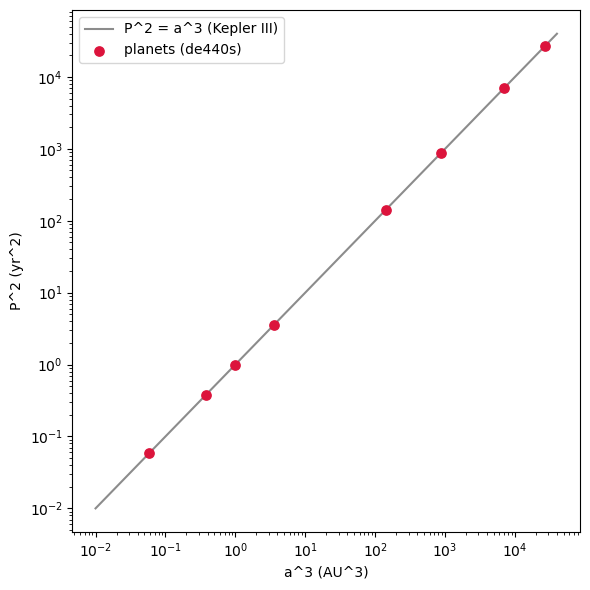

In [4]:
a = np.array([semi_major_axis(b) for b in PLANETS])
P = np.array([orbital_period(b) for b in PLANETS]) / 365.25
for b, ai, Pi in zip(PLANETS, a, P):
    print(f'{b:9s} P={Pi:8.3f} yr  a={ai:7.3f} AU  P^2/a^3={Pi**2/ai**3:.4f}')
fig, ax = plt.subplots(figsize=(6, 6))
xx = np.logspace(-2, 4.6, 50)
ax.plot(xx, xx, '-', color='0.55', label='P^2 = a^3 (Kepler III)')
ax.scatter(a**3, P**2, s=45, color='crimson', zorder=3, label='planets (de440s)')
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('a^3 (AU^3)'); ax.set_ylabel('P^2 (yr^2)'); ax.legend(); fig.tight_layout()

## 4. The orrery (top-down, J2000 ecliptic)

Orbit traces from `orbit_track`, planets at today's position. Concentric, ordered, closed orbits => the frame is right. The live version adds a date scrubber and a play button.

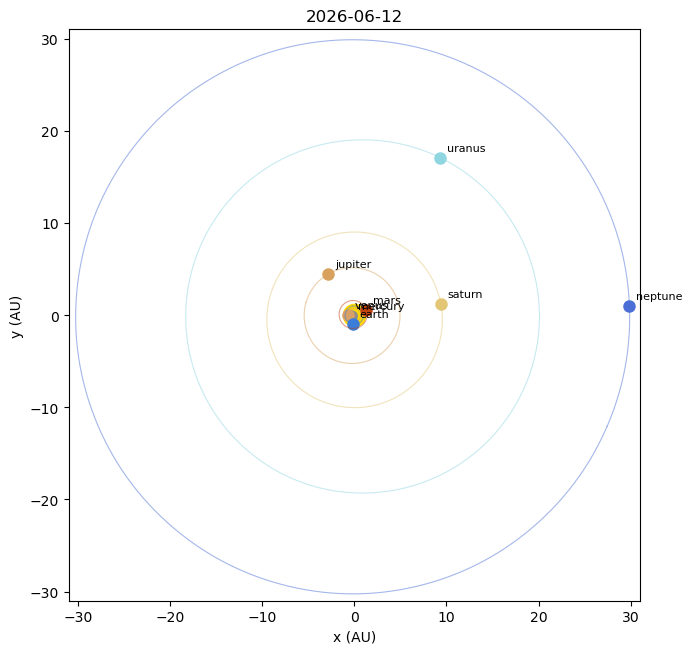

In [5]:
colors = {'mercury':'#8c8c8c','venus':'#d9a066','earth':'#3b7dd8','mars':'#c1440e',
          'jupiter':'#d8a25e','saturn':'#e3c777','uranus':'#8fd6e1','neptune':'#4b6fd6'}
fig, ax = plt.subplots(figsize=(7, 7))
ax.plot(0, 0, 'o', color='gold', ms=16)
for b in PLANETS:
    xyz = orbit_track(b, 400)
    ax.plot(xyz[0], xyz[1], '-', lw=0.8, color=colors[b], alpha=0.5)
    x, y, _ = heliocentric_ecliptic(b, t)
    ax.plot(x, y, 'o', color=colors[b], ms=8)
    ax.annotate(b, (x, y), textcoords='offset points', xytext=(5, 5), fontsize=8)
ax.set_aspect('equal'); ax.set_xlim(-31, 31); ax.set_ylim(-31, 31)
ax.set_xlabel('x (AU)'); ax.set_ylabel('y (AU)'); ax.set_title('2026-06-12'); fig.tight_layout()

## Takeaways

- Positions from JPL DE440 match the independent **Horizons** service to ~1e-10 AU - *once* the ICRF->ecliptic rotation uses the **fixed J2000** ecliptic, not Skyfield's of-date `ecliptic_frame` (which precesses away, ~0.06 AU off by 2026).
- **Kepler's third law** falls straight out of the ephemeris (P^2/a^3 = 1.000 +/- 0.001).
- A *passing* test with an **epoch-dependent** residual is a smell - chase it. The absolute Horizons check at several epochs is what exposed the of-date-vs-J2000 frame mix-up.

Run the live orrery: `streamlit run scripts/orrery.py`.